# Dynamical Analysis of SlotODE

Replacing the GRU with a continuous vector field doesn't just match performance — it makes the decomposition process mathematically analyzable. We don't set out to prove stability or chase a theorem. We set out to characterize *how the model computes*: what the dynamics look like, what phases the computation passes through, and what structure emerges from reconstruction pressure alone.

**Sections:**
1. Setup
2. Velocity profile — computational phases of the ODE
3. Jacobian eigenspectrum — spectral structure of the linearized dynamics
4. Timescale separation — fast commitment vs slow refinement
5. Cross-slot coupling — competitive dynamics and independence
6. Contraction landscape — where the dynamics contract, where they don't
7. Effective dimensionality — progressive collapse of active directions
8. Attention dynamics — entropy, sharpening, when slots commit

In [16]:
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import equinox as eqx
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import linalg as sla

from model import SlotODEModel

# ── plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "figure.facecolor": "white",
})

SLOT_CMAP = sns.color_palette("husl", 11)
ACCENT = "#2171b5"
ACCENT2 = "#cb181d"
ACCENT3 = "#238b45"

## 1. Setup

In [17]:
CKPT_PATH = "runs_data/omkos-slotode/slot_ode_11_slots_euler_T3_dt0.5/checkpoints/best.eqx"
META_PATH = CKPT_PATH.replace(".eqx", "_meta.pkl")

with open(META_PATH, "rb") as f:
    meta = pickle.load(f)
ckpt_args = meta["args"]
print(f"Checkpoint: step {meta['step']}, val_loss {meta['best_val_loss']:.6f}")
print(f"Config: T={ckpt_args['num_iter']}, dt={ckpt_args['dt']}, slots={ckpt_args['num_slots']}, dim={ckpt_args['slot_dim']}")

resolution = (ckpt_args["resolution"], ckpt_args["resolution"])
model = SlotODEModel(
    resolution=resolution,
    num_slots=ckpt_args["num_slots"],
    slot_dim=ckpt_args["slot_dim"],
    enc_hidden_dim=ckpt_args["enc_hidden_dim"],
    num_iter=ckpt_args["num_iter"],
    dt0=ckpt_args["dt"],
    key=jax.random.key(0),
)
model = eqx.tree_deserialise_leaves(CKPT_PATH, model)
model = eqx.nn.inference_mode(model)

N_SLOTS = ckpt_args["num_slots"]
SLOT_DIM = ckpt_args["slot_dim"]
FLAT_DIM = N_SLOTS * SLOT_DIM
print(f"Jacobian size: {FLAT_DIM}x{FLAT_DIM} ({N_SLOTS} slots x {SLOT_DIM} dims)")

Checkpoint: step 475000, val_loss 0.000650
Config: T=3, dt=0.5, slots=11, dim=64
Jacobian size: 704x704 (11 slots x 64 dims)


In [18]:
DATA_DIR = Path("CLEVR_64")
N_SAMPLES = 8

val_imgs = sorted((DATA_DIR / "images" / "val").glob("*.png"))
np.random.seed(7)
chosen = np.random.choice(len(val_imgs), N_SAMPLES, replace=False)
chosen.sort()

images = []
for idx in chosen:
    img = np.array(Image.open(val_imgs[idx]).convert("RGB"), dtype=np.float32) / 255.0
    img = img * 2.0 - 1.0
    img = img.transpose(2, 0, 1)
    images.append(img)
images_jax = jnp.array(np.stack(images))
print(f"Loaded {N_SAMPLES} validation images: {images_jax.shape}")

Loaded 8 validation images: (8, 3, 64, 64)


In [19]:
@eqx.filter_jit
def forward_with_traj(model, images, key):
    return model(images, key=key, return_traj=True)

key = jax.random.key(42)
recon, masks, slots, traj = forward_with_traj(model, images_jax, key)
traj_np = np.array(traj)   # [T, B, N_slots, D_slot]
masks_np = np.array(masks)  # [B, N_slots, H, W]

T_PTS = traj_np.shape[0]
T_total = float(model.slot_attention_ode.T)
dt = ckpt_args["dt"]
time_values = np.arange(T_PTS) * dt
print(f"Trajectory: {traj_np.shape} — {T_PTS} time points over T={T_total}, dt={dt}")

# precompute K, V and ODE func handle
sa = model.slot_attention_ode
enc_feat = model.enc(images_jax)
feat_norm = jax.vmap(jax.vmap(sa.norm_input))(enc_feat)
feat = jax.vmap(jax.vmap(sa.fc_input))(feat_norm)
k_all = jax.vmap(jax.vmap(sa.to_k))(feat)
v_all = jax.vmap(jax.vmap(sa.to_v))(feat)
ode_func = sa.slot_ode_func

# identify active vs background slots (by mask coverage)
slot_activity = masks_np.mean(axis=(0, 2, 3))  # [N_slots] — avg mask weight
ACTIVE_THRESH = 1.5 / N_SLOTS  # slot is "active" if it covers more than uniform share
active_slots = np.where(slot_activity > ACTIVE_THRESH)[0]
print(f"Active slots: {active_slots} (threshold={ACTIVE_THRESH:.3f})")
print(f"Slot activity: {np.array2string(slot_activity, precision=3)}")

Trajectory: (7, 8, 11, 64) — 7 time points over T=3.0, dt=0.5
Active slots: [] (threshold=0.136)
Slot activity: [0.105 0.103 0.087 0.085 0.081 0.088 0.104 0.088 0.08  0.088 0.091]


In [20]:
# ── core utilities ──────────────────────────────────────────────────────────

def compute_jacobian(img_idx, time_idx):
    """Full Jacobian df/ds at traj[time_idx, img_idx]. Returns (FLAT_DIM, FLAT_DIM) numpy."""
    slots_pt = jnp.array(traj_np[time_idx, img_idx:img_idx+1])
    k_single = k_all[img_idx:img_idx+1]
    v_single = v_all[img_idx:img_idx+1]

    def f_flat(slots_flat):
        s = slots_flat.reshape(1, N_SLOTS, SLOT_DIM)
        vel = ode_func(0.0, s, (k_single, v_single))
        return vel.flatten()

    return np.array(jax.jacfwd(f_flat)(slots_pt.flatten()))


def compute_velocity_vec(img_idx, time_idx):
    """Velocity vector f(s) at a trajectory point. Returns (FLAT_DIM,) numpy."""
    slots_pt = jnp.array(traj_np[time_idx, img_idx:img_idx+1])
    k_single = k_all[img_idx:img_idx+1]
    v_single = v_all[img_idx:img_idx+1]
    vel = ode_func(0.0, slots_pt, (k_single, v_single))
    return np.array(vel).flatten()


def compute_attention(img_idx, time_idx):
    """Compute attention weights at a trajectory point. Returns (N_slots, N_feat) numpy."""
    slots_pt = jnp.array(traj_np[time_idx, img_idx:img_idx+1])
    k_single = k_all[img_idx:img_idx+1]

    slots_norm = jax.vmap(jax.vmap(ode_func.norm_attn))(slots_pt)
    q = jnp.einsum('bnd,od->bno', slots_norm, ode_func.W_q)
    att_logits = jnp.einsum('bnd,bmd->bnm', q, k_single) * ode_func.scale
    att = jax.nn.softmax(att_logits, axis=1)  # normalize over slots
    att = att / (att.sum(axis=-1, keepdims=True) + 1e-8)
    return np.array(att[0])  # [N_slots, N_feat]


print("Utilities ready.")

Utilities ready.


## 2. Velocity Profile — Computational Phases

The velocity $\|f(s(t))\|$ tells us how hard the model is working at each point in integration time. Unlike a GRU, where each iteration is equally weighted, the ODE reveals that the computation has *phases*: an initial transient (symmetry breaking, slot assignment) and a later refinement period.

We decompose velocity per slot to see which slots are still moving and which have settled.

In [21]:
# ── Compute per-slot and total velocity norms ──────────────────────────────
# vel_per_slot[img, t, slot] = ||f_slot(s(t))||
# vel_total[img, t] = ||f(s(t))||

vel_per_slot = np.zeros((N_SAMPLES, T_PTS, N_SLOTS))
vel_total = np.zeros((N_SAMPLES, T_PTS))

for img_idx in range(N_SAMPLES):
    for t_idx in range(T_PTS):
        v = compute_velocity_vec(img_idx, t_idx)
        vel_total[img_idx, t_idx] = np.linalg.norm(v)
        v_slots = v.reshape(N_SLOTS, SLOT_DIM)
        vel_per_slot[img_idx, t_idx] = np.linalg.norm(v_slots, axis=1)

print("Velocities computed.")

Velocities computed.


/tmp/ipykernel_60243/539067590.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, ncol=2, loc="upper right")


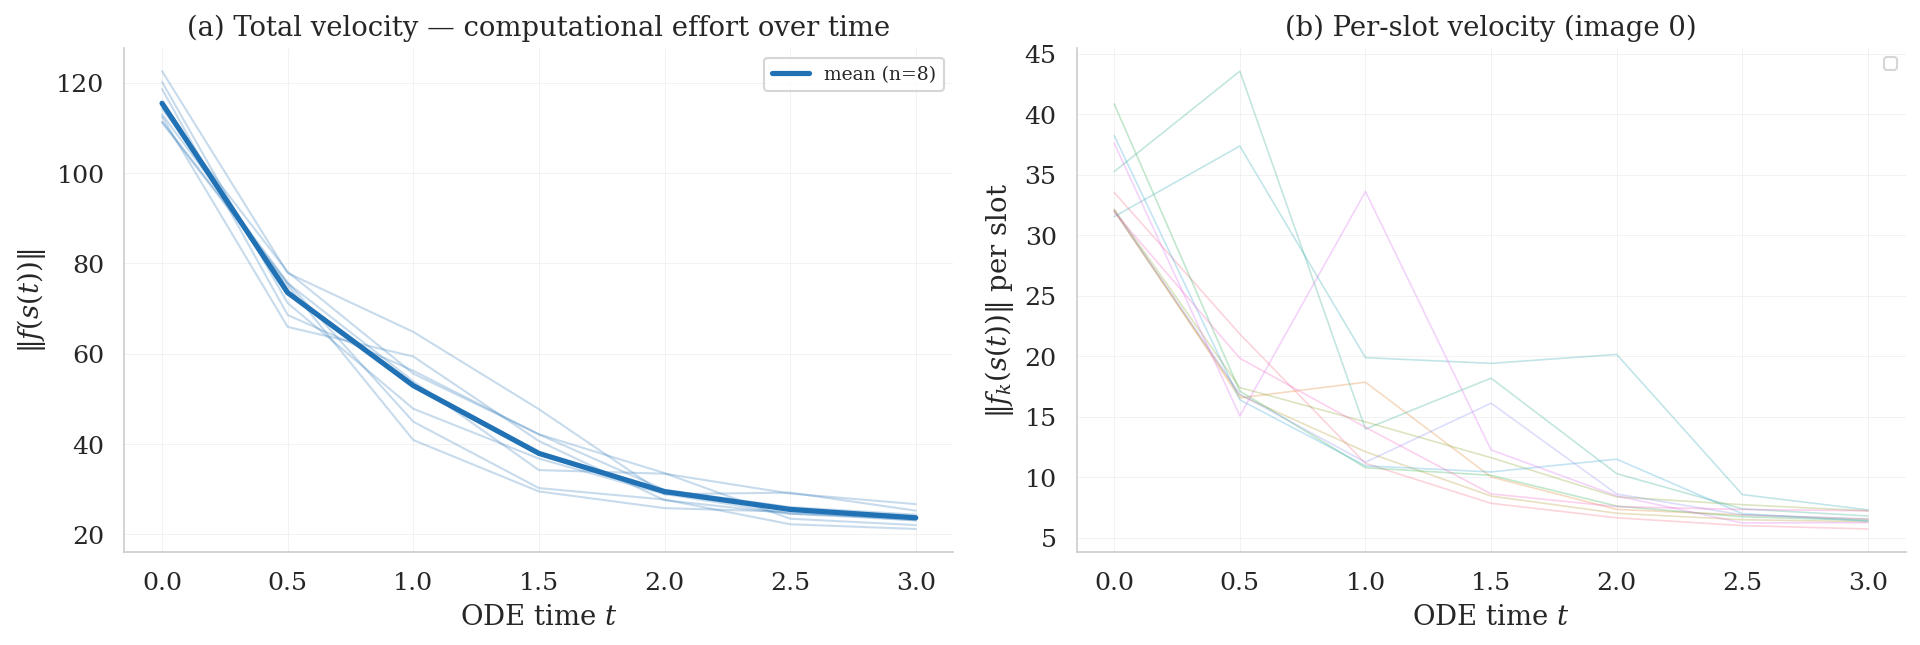

In [22]:
# ── Figure 1: Velocity profile ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Total velocity norm across images
ax = axes[0]
for img_idx in range(N_SAMPLES):
    ax.plot(time_values, vel_total[img_idx], color=ACCENT, alpha=0.25, linewidth=1)
ax.plot(time_values, vel_total.mean(axis=0), color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel(r"$\|f(s(t))\|$")
ax.set_title("(a) Total velocity — computational effort over time")
ax.legend(fontsize=9)

# (b) Per-slot velocity for one image — active vs inactive
ax = axes[1]
IMG_IDX = 0
for s_idx in range(N_SLOTS):
    is_active = s_idx in active_slots
    ax.plot(
        time_values, vel_per_slot[IMG_IDX, :, s_idx],
        color=SLOT_CMAP[s_idx], linewidth=1.8 if is_active else 0.8,
        alpha=0.9 if is_active else 0.3,
        label=f"Slot {s_idx}" if is_active else None,
    )
ax.set_xlabel("ODE time $t$")
ax.set_ylabel(r"$\|f_k(s(t))\|$ per slot")
ax.set_title("(b) Per-slot velocity (image 0)")
ax.legend(fontsize=8, ncol=2, loc="upper right")

sns.despine()
fig.tight_layout()
plt.savefig("paper/fig_velocity_profile.pdf", bbox_inches="tight")
plt.show()

## 3. Jacobian Eigenspectrum — Spectral Structure of the Dynamics

The Jacobian $J = \partial f / \partial s$ captures how the vector field responds to perturbations. Its eigenvalues reveal the *modes* of the dynamics: directions where the flow contracts (Re$(\lambda) < 0$), expands (Re$(\lambda) > 0$), or oscillates (Im$(\lambda) \neq 0$).

We don't ask "is it stable?" — we ask "what does the spectrum look like, and how does it change over integration time?" The structure of the spectrum tells us about the nature of the computation.

In [23]:
# ── Compute all Jacobians and eigenvalues ───────────────────────────────────
print(f"Computing Jacobians: {N_SAMPLES} images x {T_PTS} time steps...")
jacobians = {}   # jacobians[img][t] = J
eigenvalues = {} # eigenvalues[img][t] = complex array

for img_idx in range(N_SAMPLES):
    jacobians[img_idx] = {}
    eigenvalues[img_idx] = {}
    for t_idx in range(T_PTS):
        J = compute_jacobian(img_idx, t_idx)
        jacobians[img_idx][t_idx] = J
        eigenvalues[img_idx][t_idx] = sla.eigvals(J)
    print(f"  Image {img_idx}: done")

print("All Jacobians computed.")

Computing Jacobians: 8 images x 7 time steps...
  Image 0: done
  Image 1: done
  Image 2: done
  Image 3: done
  Image 4: done
  Image 5: done
  Image 6: done
  Image 7: done
All Jacobians computed.


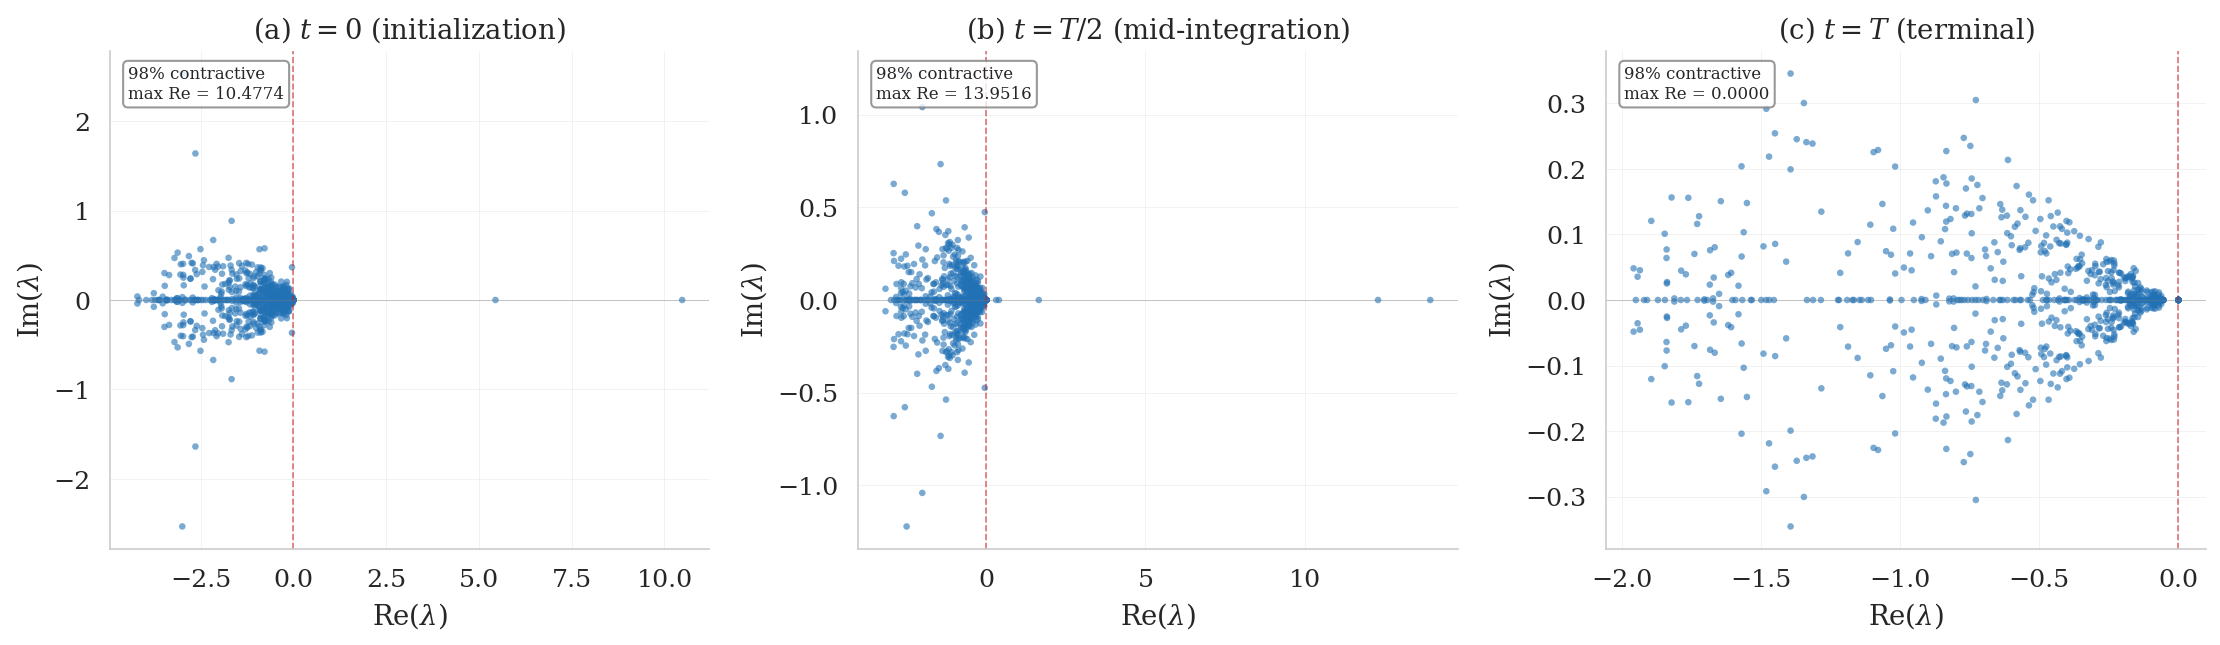

In [24]:
# ── Figure 2: Eigenvalue spectrum — evolution over time ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# one image, three time points: early / mid / terminal
IMG_IDX = 0
t_indices = [0, T_PTS // 2, T_PTS - 1]
panel_labels = ["(a) $t = 0$ (initialization)", "(b) $t = T/2$ (mid-integration)", "(c) $t = T$ (terminal)"]

for ax, ti, label in zip(axes, t_indices, panel_labels):
    eigs = eigenvalues[IMG_IDX][ti]
    ax.scatter(eigs.real, eigs.imag, s=10, alpha=0.6, color=ACCENT, edgecolors="none")
    ax.axvline(0, color=ACCENT2, linewidth=0.8, linestyle="--", alpha=0.6)
    ax.axhline(0, color="grey", linewidth=0.5, alpha=0.4)
    ax.set_xlabel(r"Re$(\lambda)$")
    ax.set_ylabel(r"Im$(\lambda)$")
    ax.set_title(label)

    neg_frac = np.mean(eigs.real < 0) * 100
    max_re = np.max(eigs.real)
    ax.annotate(
        f"{neg_frac:.0f}% contractive\nmax Re = {max_re:.4f}",
        xy=(0.03, 0.97), xycoords="axes fraction", fontsize=8,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.8),
    )

sns.despine()
fig.tight_layout()
plt.savefig("paper/fig_eigenspectrum_evolution.pdf", bbox_inches="tight")
plt.show()

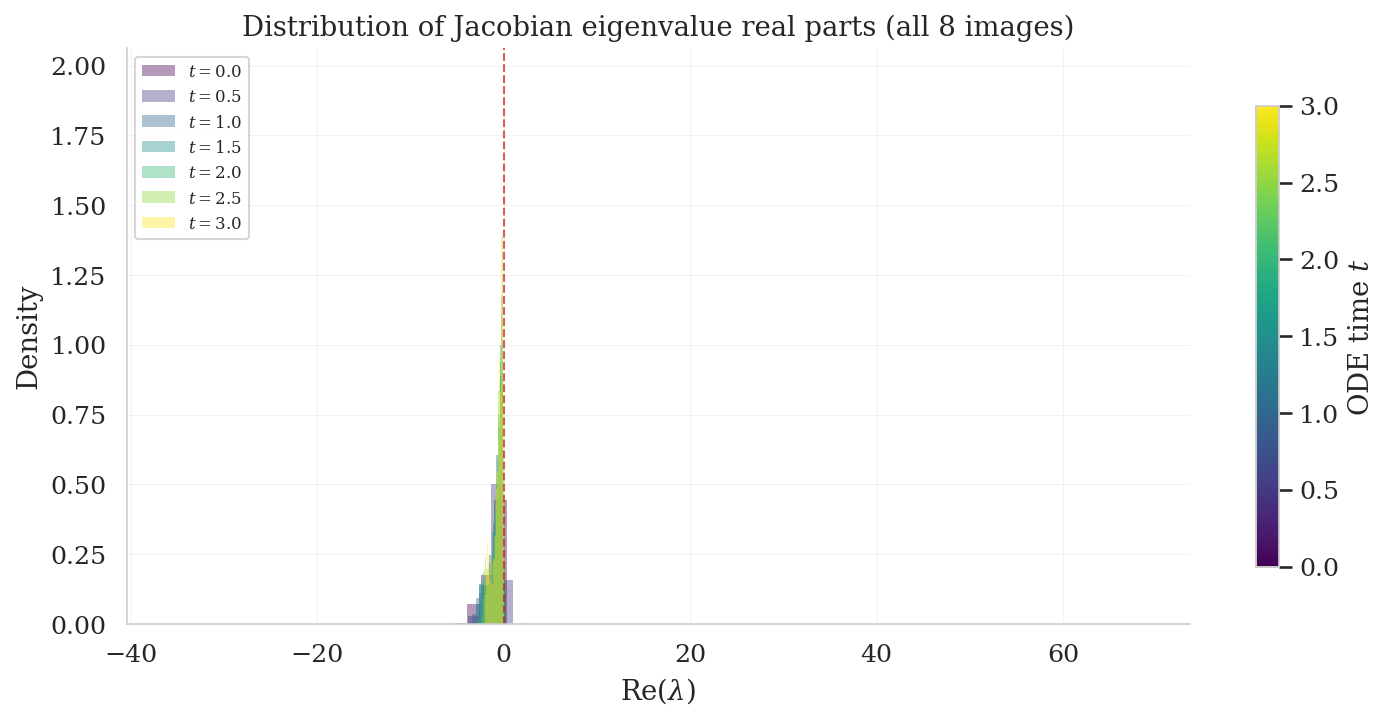

In [25]:
# ── Figure 3: Eigenvalue distribution as histograms at each time step ───────
# Shows how the Re(lambda) distribution shifts over integration time.

fig, ax = plt.subplots(figsize=(10, 5))

cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=time_values[0], vmax=time_values[-1])

for t_idx in range(T_PTS):
    all_re = np.concatenate([eigenvalues[i][t_idx].real for i in range(N_SAMPLES)])
    color = cmap(norm(time_values[t_idx]))
    ax.hist(
        all_re, bins=60, alpha=0.4, color=color, edgecolor="none",
        density=True, label=f"$t={time_values[t_idx]:.1f}$",
    )

ax.axvline(0, color=ACCENT2, linewidth=1, linestyle="--", alpha=0.7)
ax.set_xlabel(r"Re$(\lambda)$")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of Jacobian eigenvalue real parts (all {N_SAMPLES} images)")
ax.legend(fontsize=8, loc="upper left")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("ODE time $t$")

sns.despine()
fig.tight_layout()
plt.savefig("paper/fig_eigenvalue_distribution.pdf", bbox_inches="tight")
plt.show()

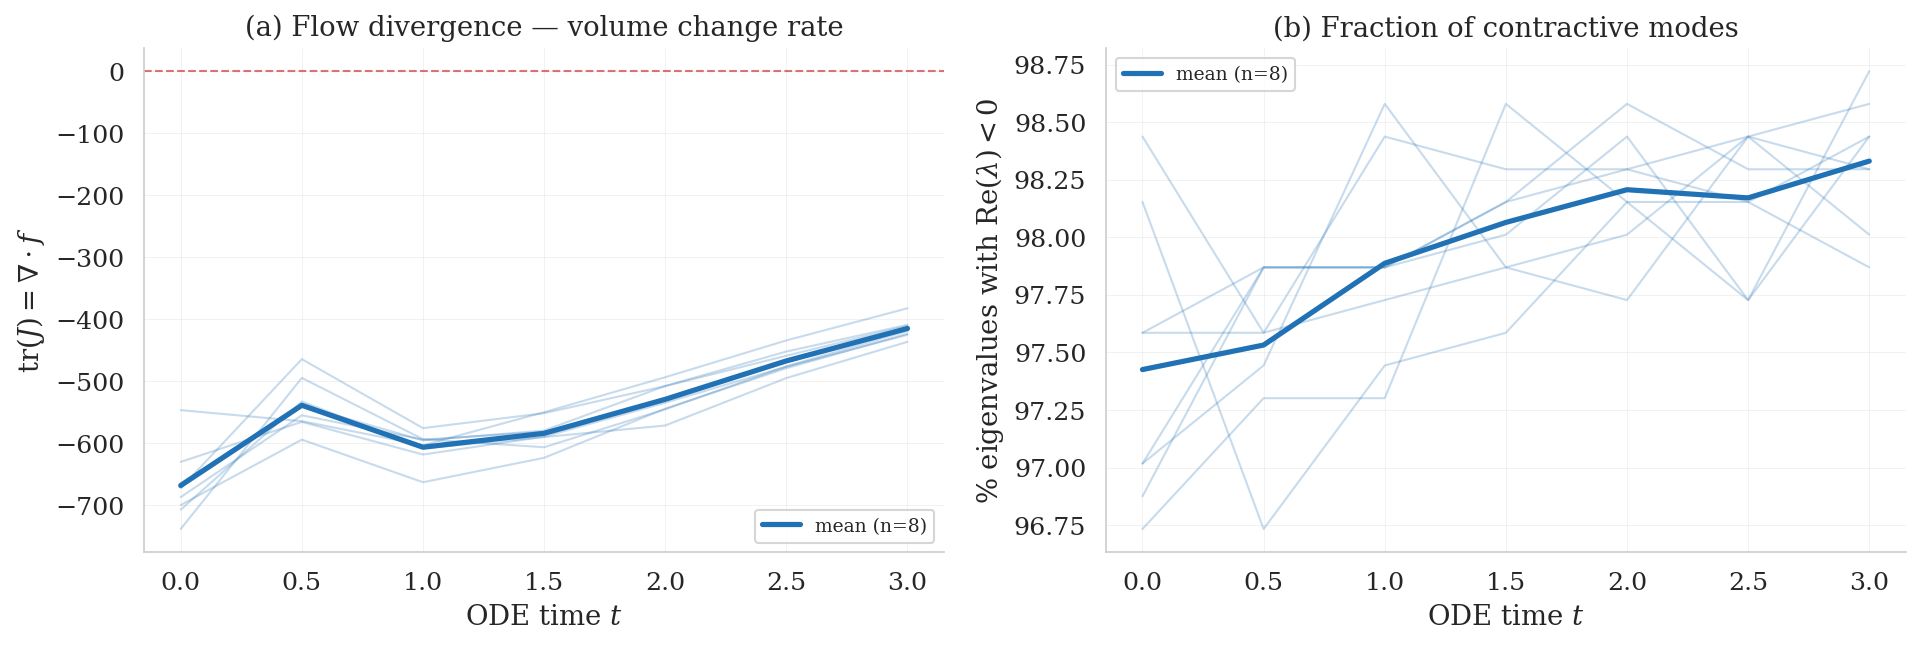

In [26]:
# ── Figure 4: Divergence (trace) and fraction of contractive eigenvalues ────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) tr(J) = div(f) — volume change rate
ax = axes[0]
for img_idx in range(N_SAMPLES):
    traces = [np.real(np.trace(jacobians[img_idx][t])) for t in range(T_PTS)]
    ax.plot(time_values, traces, color=ACCENT, alpha=0.25, linewidth=1)

mean_trace = np.array([
    np.mean([np.real(np.trace(jacobians[i][t])) for i in range(N_SAMPLES)])
    for t in range(T_PTS)
])
ax.plot(time_values, mean_trace, color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.axhline(0, color=ACCENT2, linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("ODE time $t$")
ax.set_ylabel(r"tr$(J) = \nabla \cdot f$")
ax.set_title("(a) Flow divergence — volume change rate")
ax.legend(fontsize=9)

# (b) Fraction of eigenvalues with Re < 0
ax = axes[1]
for img_idx in range(N_SAMPLES):
    fracs = [np.mean(eigenvalues[img_idx][t].real < 0) * 100 for t in range(T_PTS)]
    ax.plot(time_values, fracs, color=ACCENT, alpha=0.25, linewidth=1)

mean_frac = np.array([
    np.mean([np.mean(eigenvalues[i][t].real < 0) * 100 for i in range(N_SAMPLES)])
    for t in range(T_PTS)
])
ax.plot(time_values, mean_frac, color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel("% eigenvalues with Re$(\\lambda) < 0$")
ax.set_title("(b) Fraction of contractive modes")
ax.legend(fontsize=9)

sns.despine()
fig.tight_layout()
plt.savefig("paper/fig_divergence_and_fraction.pdf", bbox_inches="tight")
plt.show()

## 4. Timescale Separation

The *magnitudes* of the eigenvalues reveal the timescales of the dynamics. Large $|\lambda|$ directions evolve quickly (fast modes — slot assignment, symmetry breaking), while small $|\lambda|$ directions evolve slowly (slow modes — feature refinement, fine adjustments).

A gap in the eigenvalue magnitude spectrum indicates **timescale separation**: the system decomposes into fast and slow subsystems. This is a hallmark of well-structured dynamics in physical and biological systems.

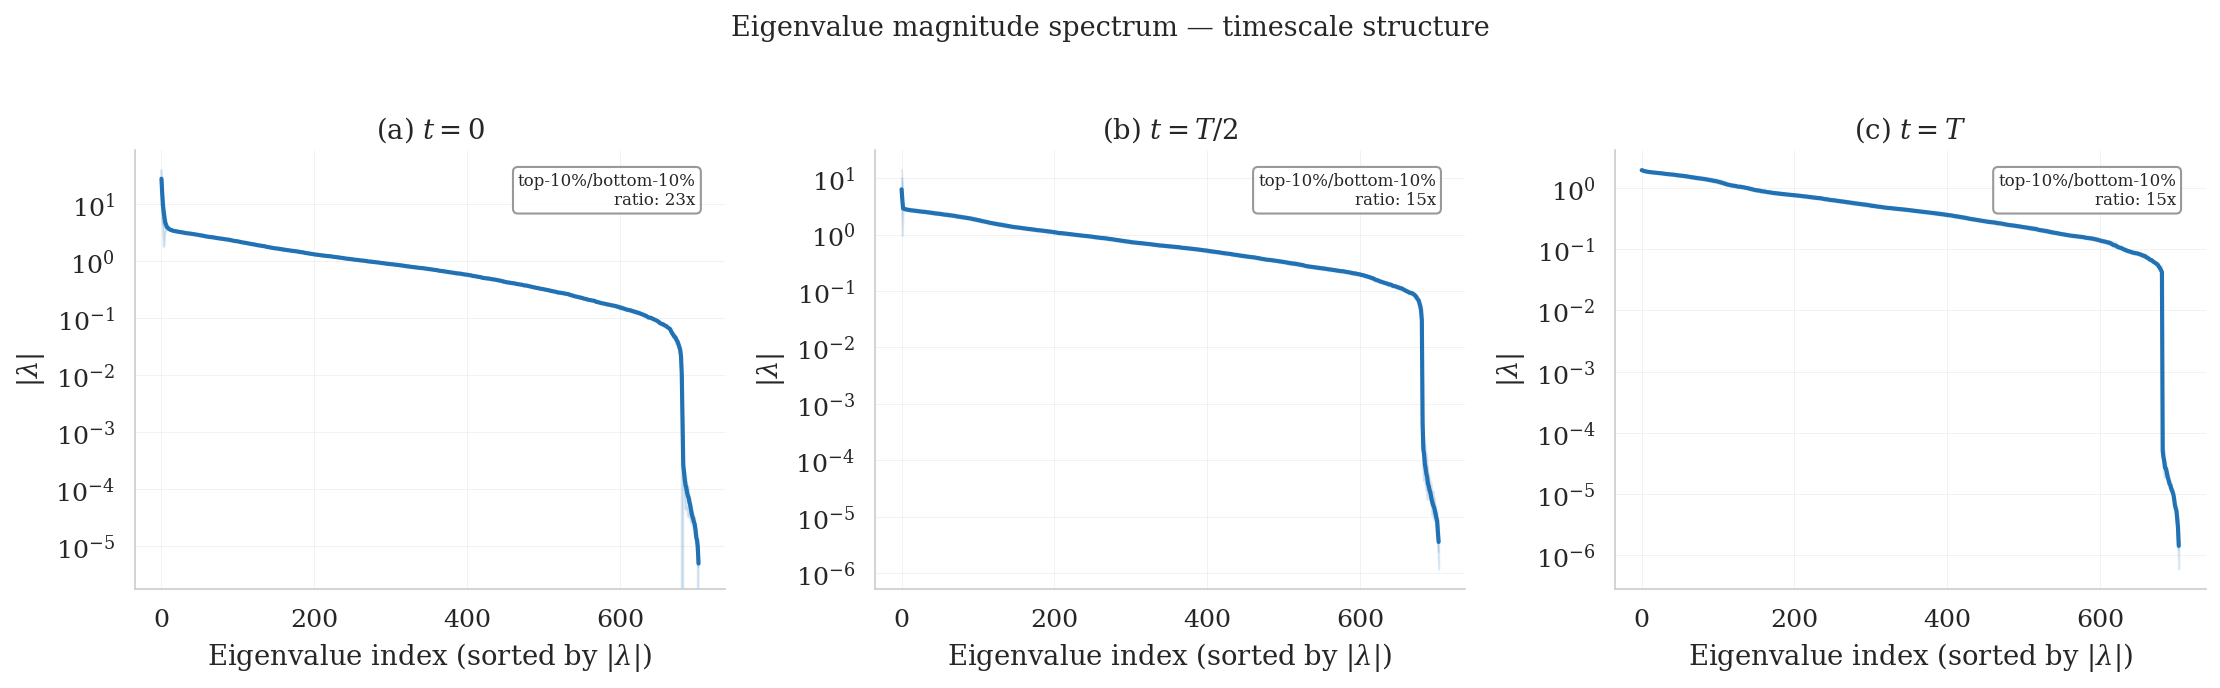

In [27]:
# ── Figure 5: Eigenvalue magnitude spectrum (sorted) at each time step ──────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

IMG_IDX = 0
t_indices = [0, T_PTS // 2, T_PTS - 1]
panel_labels = ["(a) $t = 0$", "(b) $t = T/2$", "(c) $t = T$"]

for ax, ti, label in zip(axes, t_indices, panel_labels):
    # average magnitude spectrum across all images
    all_mags = []
    for img_idx in range(N_SAMPLES):
        mags = np.sort(np.abs(eigenvalues[img_idx][ti]))[::-1]
        all_mags.append(mags)
        if img_idx == IMG_IDX:
            ax.plot(range(len(mags)), mags, color=ACCENT, alpha=0.15, linewidth=0.8)

    mean_mags = np.mean(all_mags, axis=0)
    std_mags = np.std(all_mags, axis=0)
    x = np.arange(len(mean_mags))
    ax.fill_between(x, mean_mags - std_mags, mean_mags + std_mags, color=ACCENT, alpha=0.15)
    ax.plot(x, mean_mags, color=ACCENT, linewidth=2)

    ax.set_xlabel("Eigenvalue index (sorted by $|\\lambda|$)")
    ax.set_ylabel("$|\\lambda|$")
    ax.set_title(label)
    ax.set_yscale("log")

    # annotate the spectral gap
    ratio_10_90 = mean_mags[int(0.1 * len(mean_mags))] / mean_mags[int(0.9 * len(mean_mags))]
    ax.annotate(
        f"top-10%/bottom-10%\nratio: {ratio_10_90:.0f}x",
        xy=(0.95, 0.95), xycoords="axes fraction", fontsize=8,
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.8),
    )

sns.despine()
fig.suptitle("Eigenvalue magnitude spectrum — timescale structure", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("paper/fig_timescale_separation.pdf", bbox_inches="tight")
plt.show()

## 5. Cross-Slot Coupling

The Jacobian has a natural $N_{\text{slots}} \times N_{\text{slots}}$ block structure, where block $(i, j)$ of size $D \times D$ captures how slot $j$'s state influences slot $i$'s velocity: $\partial f_i / \partial s_j$.

- **Diagonal blocks** $(i = j)$: self-dynamics — how a slot's own state drives its evolution
- **Off-diagonal blocks** $(i \neq j)$: cross-slot coupling — the competitive interaction mediated by softmax attention

If coupling weakens over time, slots are becoming independent — they've "decided" which object to attend to and no longer compete. The ratio of diagonal to off-diagonal energy reveals this transition.

In [28]:
# ── Compute block norms and coupling metrics ────────────────────────────────

def slot_block_norms(J, n_slots, d_slot):
    """Frobenius norm of each (i, j) slot-slot block."""
    B = np.zeros((n_slots, n_slots))
    for i in range(n_slots):
        for j in range(n_slots):
            block = J[i*d_slot:(i+1)*d_slot, j*d_slot:(j+1)*d_slot]
            B[i, j] = np.linalg.norm(block, ord="fro")
    return B


def coupling_ratio(block_norms):
    """Ratio of mean off-diagonal to mean diagonal block norm."""
    n = block_norms.shape[0]
    diag = np.mean(np.diag(block_norms))
    off_diag = np.mean(block_norms[~np.eye(n, dtype=bool)])
    return off_diag / (diag + 1e-12)


# compute for all images and time steps
block_norms_all = {}  # block_norms_all[img][t] = (N_SLOTS, N_SLOTS)
coupling_ratios = np.zeros((N_SAMPLES, T_PTS))

for img_idx in range(N_SAMPLES):
    block_norms_all[img_idx] = {}
    for t_idx in range(T_PTS):
        bn = slot_block_norms(jacobians[img_idx][t_idx], N_SLOTS, SLOT_DIM)
        block_norms_all[img_idx][t_idx] = bn
        coupling_ratios[img_idx, t_idx] = coupling_ratio(bn)

print("Block norms computed.")

Block norms computed.


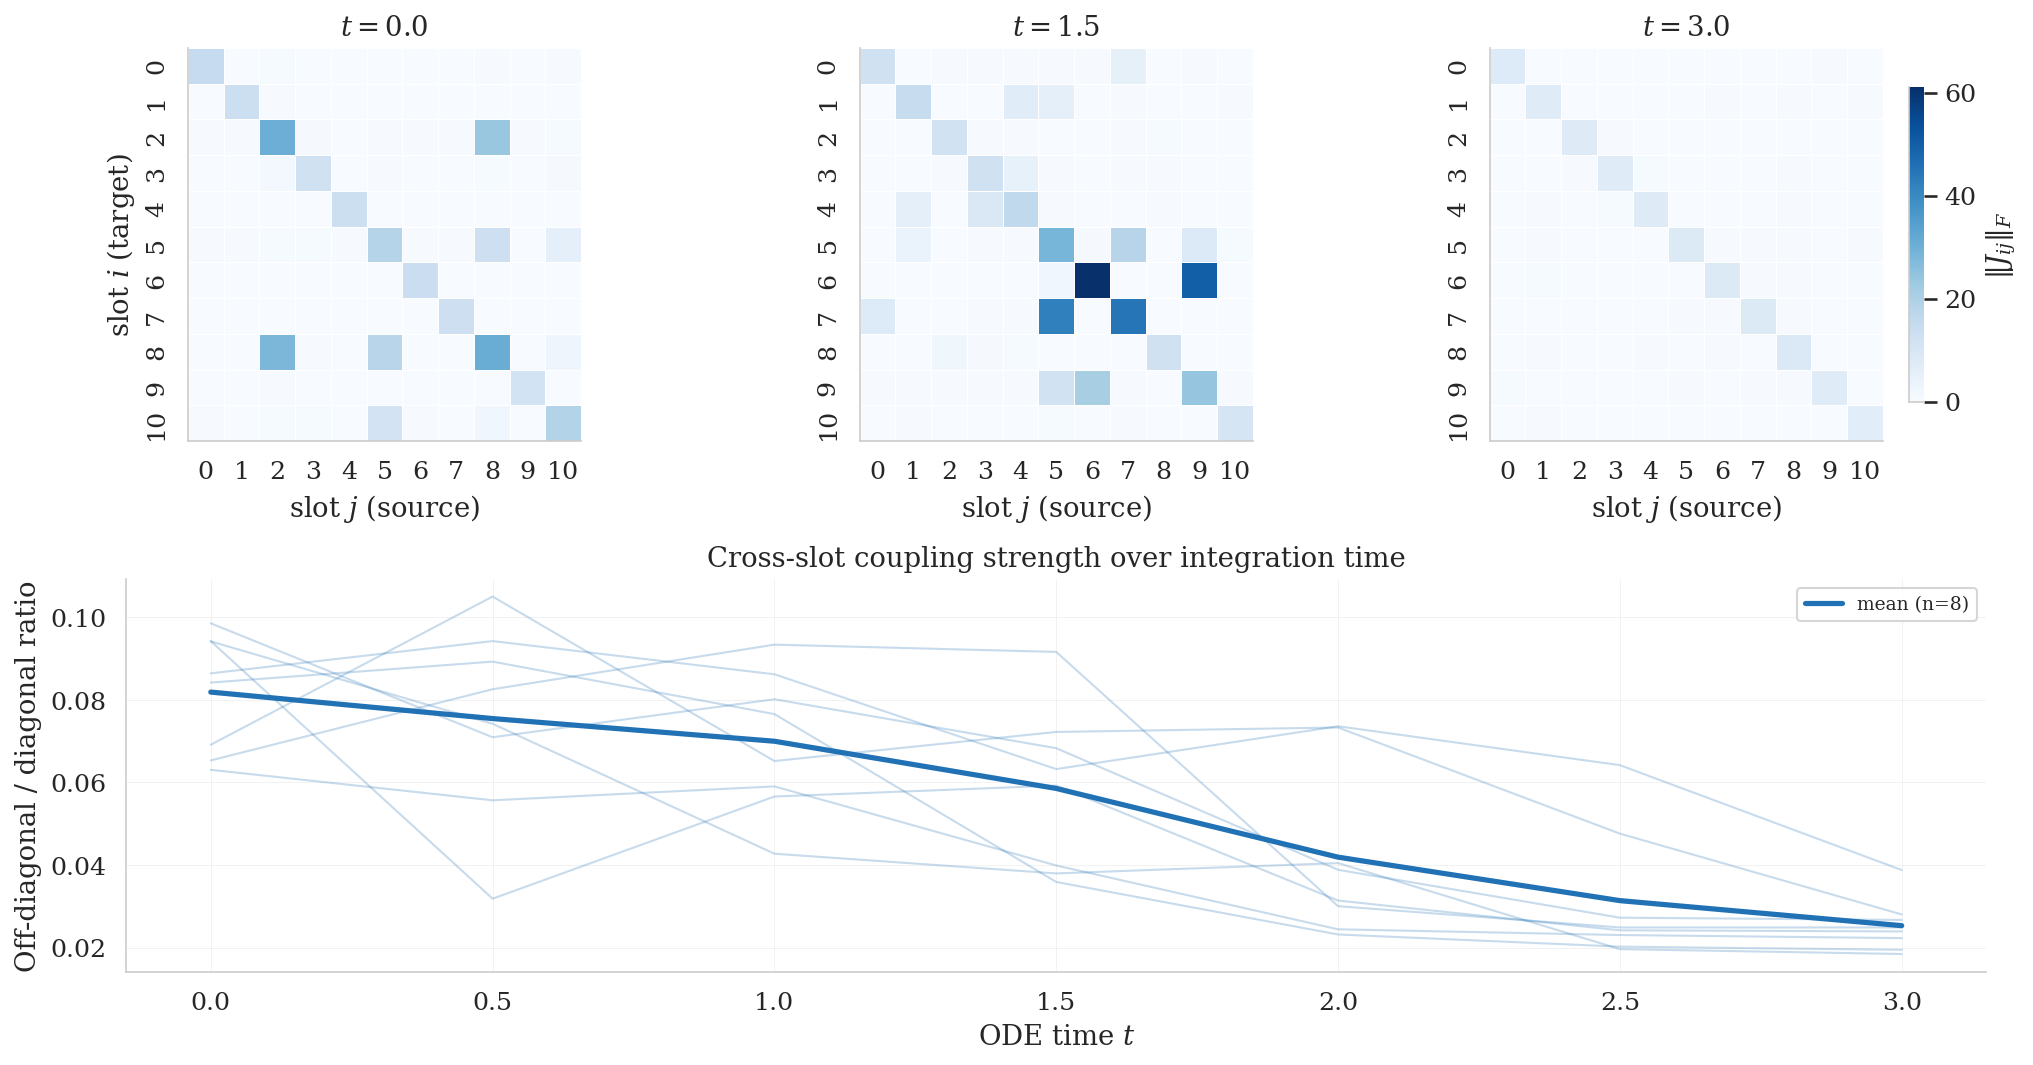

In [29]:
# ── Figure 6: Cross-slot coupling ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))

# Top row: heatmaps at t=0, T/2, T
IMG_IDX = 0
t_indices = [0, T_PTS // 2, T_PTS - 1]
t_labels = [f"$t = {time_values[ti]:.1f}$" for ti in t_indices]

# compute shared vmax across all three panels
vmax = max(block_norms_all[IMG_IDX][ti].max() for ti in t_indices)

gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

for col, (ti, label) in enumerate(zip(t_indices, t_labels)):
    ax = fig.add_subplot(gs[0, col])
    bn = block_norms_all[IMG_IDX][ti]
    sns.heatmap(
        bn, ax=ax, cmap="Blues", vmin=0, vmax=vmax,
        square=True, cbar=col == 2,
        cbar_kws={"shrink": 0.8, "label": r"$\|J_{ij}\|_F$"} if col == 2 else {},
        xticklabels=range(N_SLOTS), yticklabels=range(N_SLOTS),
        linewidths=0.3, linecolor="white",
    )
    ax.set_title(label)
    ax.set_xlabel("slot $j$ (source)")
    ax.set_ylabel("slot $i$ (target)" if col == 0 else "")

# Bottom row: coupling ratio over time
ax = fig.add_subplot(gs[1, :])
for img_idx in range(N_SAMPLES):
    ax.plot(time_values, coupling_ratios[img_idx], color=ACCENT, alpha=0.25, linewidth=1)
ax.plot(time_values, coupling_ratios.mean(axis=0), color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel("Off-diagonal / diagonal ratio")
ax.set_title("Cross-slot coupling strength over integration time")
ax.legend(fontsize=9)

sns.despine()
plt.savefig("paper/fig_cross_slot_coupling.pdf", bbox_inches="tight")
plt.show()

## 6. Contraction Landscape

Rather than asking "is the system contracting everywhere?", we map *where* it contracts and where it doesn't.

The symmetric part $S = (J + J^\top) / 2$ determines contraction in the Euclidean norm: $\lambda_{\max}(S) < 0$ means the system is locally contracting. We also decompose: what fraction of the spectrum of $S$ is negative at each time step?

This reveals the transition from the initial transient (possibly non-contracting — symmetry breaking requires expansion) to the later convergent phase.

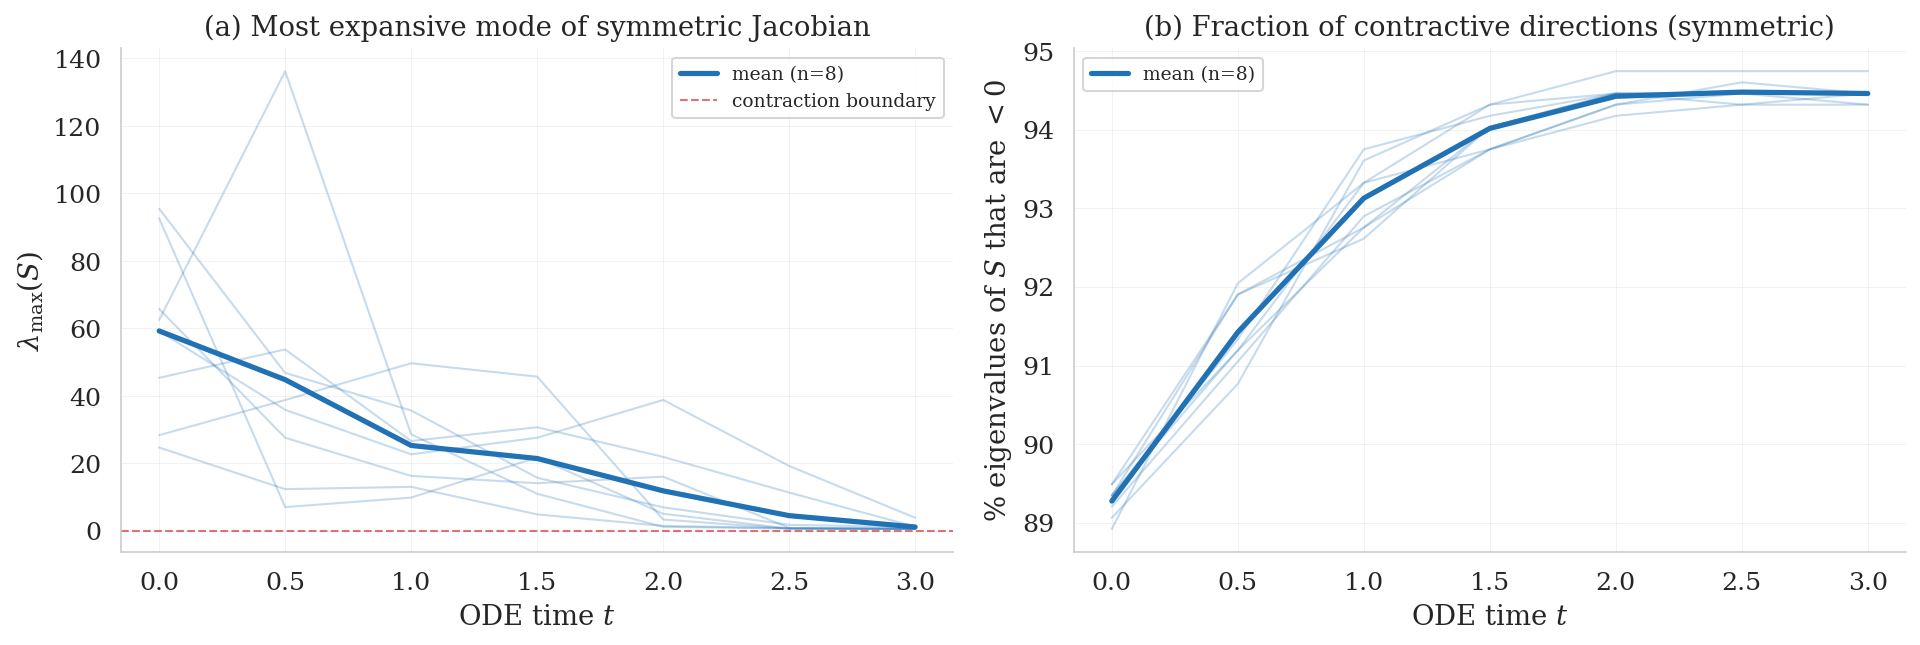

t=0.0: max_eig(S) = 59.2496 ± 24.5437, 89.3% contractive
t=1.5: max_eig(S) = 21.4439 ± 12.1544, 94.0% contractive
t=3.0: max_eig(S) = 1.1513 ± 1.0680, 94.5% contractive


In [30]:
# ── Symmetric Jacobian analysis ─────────────────────────────────────────────
sym_max_eig = np.zeros((N_SAMPLES, T_PTS))
sym_frac_neg = np.zeros((N_SAMPLES, T_PTS))
sym_spectra = {}  # sym_spectra[img][t] = sorted eigenvalues of S

for img_idx in range(N_SAMPLES):
    sym_spectra[img_idx] = {}
    for t_idx in range(T_PTS):
        J = jacobians[img_idx][t_idx]
        S = (J + J.T) / 2
        eigs_s = np.sort(sla.eigvalsh(S))  # real, sorted ascending
        sym_spectra[img_idx][t_idx] = eigs_s
        sym_max_eig[img_idx, t_idx] = eigs_s[-1]
        sym_frac_neg[img_idx, t_idx] = np.mean(eigs_s < 0) * 100

# ── Figure 7: Contraction landscape ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Max eigenvalue of S
ax = axes[0]
for img_idx in range(N_SAMPLES):
    ax.plot(time_values, sym_max_eig[img_idx], color=ACCENT, alpha=0.25, linewidth=1)
ax.plot(time_values, sym_max_eig.mean(axis=0), color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.axhline(0, color=ACCENT2, linewidth=1, linestyle="--", alpha=0.6, label="contraction boundary")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel(r"$\lambda_{\max}(S)$")
ax.set_title("(a) Most expansive mode of symmetric Jacobian")
ax.legend(fontsize=9)

# (b) Fraction of contractive modes in S
ax = axes[1]
for img_idx in range(N_SAMPLES):
    ax.plot(time_values, sym_frac_neg[img_idx], color=ACCENT, alpha=0.25, linewidth=1)
ax.plot(time_values, sym_frac_neg.mean(axis=0), color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel("% eigenvalues of $S$ that are $< 0$")
ax.set_title("(b) Fraction of contractive directions (symmetric)")
ax.legend(fontsize=9)

sns.despine()
fig.tight_layout()
plt.savefig("paper/fig_contraction_landscape.pdf", bbox_inches="tight")
plt.show()

# print transition summary
for t_idx in [0, T_PTS//2, T_PTS-1]:
    print(f"t={time_values[t_idx]:.1f}: max_eig(S) = {sym_max_eig[:, t_idx].mean():.4f} ± {sym_max_eig[:, t_idx].std():.4f}, "
          f"{sym_frac_neg[:, t_idx].mean():.1f}% contractive")

## 7. Effective Dimensionality

How many directions in slot space carry significant dynamical weight? We measure this via the **participation ratio** of eigenvalue magnitudes:

$$d_{\text{eff}} = \frac{\left(\sum_i |\lambda_i|\right)^2}{\sum_i |\lambda_i|^2}$$

This equals $N$ when all modes contribute equally (high-dimensional dynamics) and approaches 1 when a single mode dominates. A decrease over integration time means the dynamics are collapsing onto fewer active directions — the computation is "focusing."

In [ ]:
def participation_ratio(eigs):
    mags = np.abs(eigs)
    mags = mags[mags > 1e-12]
    return (mags.sum() ** 2) / (mags ** 2).sum()

eff_dims = np.zeros((N_SAMPLES, T_PTS))
for img_idx in range(N_SAMPLES):
    for t_idx in range(T_PTS):
        eff_dims[img_idx, t_idx] = participation_ratio(eigenvalues[img_idx][t_idx])

# also compute via singular values (more robust for non-normal matrices)
eff_dims_sv = np.zeros((N_SAMPLES, T_PTS))
for img_idx in range(N_SAMPLES):
    for t_idx in range(T_PTS):
        sv = sla.svdvals(jacobians[img_idx][t_idx])
        sv = sv[sv > 1e-12]
        eff_dims_sv[img_idx, t_idx] = (sv.sum() ** 2) / (sv ** 2).sum()

# ── Figure 8: Effective dimensionality ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) via eigenvalues
ax = axes[0]
for img_idx in range(N_SAMPLES):
    ax.plot(time_values, eff_dims[img_idx], color=ACCENT, alpha=0.25, linewidth=1)
ax.plot(time_values, eff_dims.mean(axis=0), color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.axhline(FLAT_DIM, color="grey", linewidth=0.8, linestyle=":", alpha=0.5, label=f"full rank ({FLAT_DIM})")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel(r"$d_{\mathrm{eff}}$ (eigenvalue PR)")
ax.set_title("(a) Effective dim via eigenvalue magnitudes")
ax.legend(fontsize=9)

# (b) via singular values (more robust for non-normal J)
ax = axes[1]
for img_idx in range(N_SAMPLES):
    ax.plot(time_values, eff_dims_sv[img_idx], color=ACCENT3, alpha=0.25, linewidth=1)
ax.plot(time_values, eff_dims_sv.mean(axis=0), color=ACCENT3, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.axhline(FLAT_DIM, color="grey", linewidth=0.8, linestyle=":", alpha=0.5, label=f"full rank ({FLAT_DIM})")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel(r"$d_{\mathrm{eff}}$ (singular value PR)")
ax.set_title("(b) Effective dim via singular values")
ax.legend(fontsize=9)

sns.despine()
fig.tight_layout()
plt.savefig("paper/fig_effective_dim.pdf", bbox_inches="tight")
plt.show()

mean_eff = eff_dims.mean(axis=0)
print(f"d_eff (eigenvalues): t=0 → {mean_eff[0]:.1f}, t=T → {mean_eff[-1]:.1f}")
mean_sv = eff_dims_sv.mean(axis=0)
print(f"d_eff (singular values): t=0 → {mean_sv[0]:.1f}, t=T → {mean_sv[-1]:.1f}")

## 8. Attention Dynamics

The attention weights are the interface between slots and the scene. Their evolution reveals when slots *commit* to objects.

- **Entropy** of each slot's attention distribution: high entropy = diffuse attention (slot hasn't decided), low entropy = concentrated (slot is locked onto an object)
- **Max attention weight** per slot: how confident is the strongest assignment?

The transition from high to low entropy is the continuous-time analogue of the discrete "slot assignment" event in standard Slot Attention.

In [ ]:
# ── Compute attention entropy over time ─────────────────────────────────────

def attention_entropy(att):
    """Per-slot entropy of attention weights. att: (N_slots, N_feat)."""
    # clip to avoid log(0)
    att_safe = np.clip(att, 1e-12, None)
    ent = -np.sum(att_safe * np.log(att_safe), axis=1)  # [N_slots]
    return ent

# att_entropy[img][t] = [N_slots] array
att_entropy_all = np.zeros((N_SAMPLES, T_PTS, N_SLOTS))
att_max_all = np.zeros((N_SAMPLES, T_PTS, N_SLOTS))

for img_idx in range(N_SAMPLES):
    for t_idx in range(T_PTS):
        att = compute_attention(img_idx, t_idx)  # [N_slots, N_feat]
        att_entropy_all[img_idx, t_idx] = attention_entropy(att)
        att_max_all[img_idx, t_idx] = att.max(axis=1)

# max possible entropy = log(N_feat) = log(H*W) = log(4096)
N_FEAT = 64 * 64
max_entropy = np.log(N_FEAT)
print(f"Attention computed. Max possible entropy: {max_entropy:.2f} (uniform over {N_FEAT} features)")

In [ ]:
# ── Figure 9: Attention dynamics ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Mean entropy across slots — per image
ax = axes[0]
mean_ent_per_img = att_entropy_all.mean(axis=2)  # [N_SAMPLES, T_PTS]
for img_idx in range(N_SAMPLES):
    ax.plot(time_values, mean_ent_per_img[img_idx], color=ACCENT, alpha=0.25, linewidth=1)
ax.plot(time_values, mean_ent_per_img.mean(axis=0), color=ACCENT, linewidth=2.5, label=f"mean (n={N_SAMPLES})")
ax.axhline(max_entropy, color="grey", linewidth=0.8, linestyle=":", alpha=0.5, label=f"uniform ({max_entropy:.1f})")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel("Attention entropy (nats)")
ax.set_title("(a) Mean attention entropy per slot")
ax.legend(fontsize=9)

# (b) Per-slot entropy for one image — active vs inactive
ax = axes[1]
IMG_IDX = 0
for s_idx in range(N_SLOTS):
    is_active = s_idx in active_slots
    ax.plot(
        time_values, att_entropy_all[IMG_IDX, :, s_idx],
        color=SLOT_CMAP[s_idx], linewidth=1.8 if is_active else 0.8,
        alpha=0.9 if is_active else 0.3,
        label=f"Slot {s_idx}" if is_active else None,
    )
ax.set_xlabel("ODE time $t$")
ax.set_ylabel("Attention entropy (nats)")
ax.set_title("(b) Per-slot entropy (image 0)")
ax.legend(fontsize=8, ncol=2, loc="upper right")

sns.despine()
fig.tight_layout()
plt.savefig("paper/fig_attention_dynamics.pdf", bbox_inches="tight")
plt.show()

## 9. Summary

In [ ]:
print("=" * 78)
print("DYNAMICAL ANALYSIS SUMMARY")
print("=" * 78)

print("\n── Velocity Profile ──")
print(f"  ||f|| at t=0:  {vel_total[:, 0].mean():.2f} ± {vel_total[:, 0].std():.2f}")
print(f"  ||f|| at t=T:  {vel_total[:, -1].mean():.4f} ± {vel_total[:, -1].std():.4f}")
print(f"  Reduction:     {(1 - vel_total[:, -1].mean() / vel_total[:, 0].mean()) * 100:.1f}%")

print("\n── Jacobian Eigenspectrum ──")
for t_idx in [0, T_PTS//2, T_PTS-1]:
    neg_fracs = [np.mean(eigenvalues[i][t_idx].real < 0) * 100 for i in range(N_SAMPLES)]
    max_res = [np.max(eigenvalues[i][t_idx].real) for i in range(N_SAMPLES)]
    print(f"  t={time_values[t_idx]:.1f}: {np.mean(neg_fracs):.1f}% contractive, "
          f"max Re(λ) = {np.mean(max_res):.4f} ± {np.std(max_res):.4f}")

print("\n── Divergence ──")
for t_idx in [0, T_PTS//2, T_PTS-1]:
    traces = [np.real(np.trace(jacobians[i][t_idx])) for i in range(N_SAMPLES)]
    print(f"  t={time_values[t_idx]:.1f}: tr(J) = {np.mean(traces):.1f} ± {np.std(traces):.1f}")

print("\n── Cross-Slot Coupling ──")
print(f"  Coupling ratio at t=0: {coupling_ratios[:, 0].mean():.3f}")
print(f"  Coupling ratio at t=T: {coupling_ratios[:, -1].mean():.3f}")
direction = "decreasing" if coupling_ratios[:, -1].mean() < coupling_ratios[:, 0].mean() else "increasing"
print(f"  Trend: {direction} (slots becoming {'more independent' if direction == 'decreasing' else 'more coupled'})")

print("\n── Contraction (Symmetric Jacobian) ──")
for t_idx in [0, T_PTS//2, T_PTS-1]:
    print(f"  t={time_values[t_idx]:.1f}: max eig(S) = {sym_max_eig[:, t_idx].mean():.4f} ± {sym_max_eig[:, t_idx].std():.4f}, "
          f"{sym_frac_neg[:, t_idx].mean():.1f}% contractive")

print("\n── Effective Dimensionality ──")
print(f"  d_eff (eig) at t=0: {eff_dims[:, 0].mean():.1f}, t=T: {eff_dims[:, -1].mean():.1f} (of {FLAT_DIM})")
print(f"  d_eff (sv)  at t=0: {eff_dims_sv[:, 0].mean():.1f}, t=T: {eff_dims_sv[:, -1].mean():.1f} (of {FLAT_DIM})")

print("\n── Attention Entropy ──")
print(f"  Mean entropy at t=0: {att_entropy_all[:, 0, :].mean():.2f} (max={max_entropy:.2f})")
print(f"  Mean entropy at t=T: {att_entropy_all[:, -1, :].mean():.2f}")
entropy_drop = (1 - att_entropy_all[:, -1, :].mean() / att_entropy_all[:, 0, :].mean()) * 100
print(f"  Entropy reduction:   {entropy_drop:.1f}%")

print("\n" + "=" * 78)